In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from opacus import PrivacyEngine
import optuna
import sys
from functools import partial
import random
import numpy as np
import time
import os
import pickle
from scipy.stats import skewnorm
import os
import seaborn as sns

# Experiment parameters

In [2]:
def seed_everything(seed):
    # Set random seed for reproducibility
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

In [3]:
os.makedirs('./toy-model-data', exist_ok=True)
os.makedirs('./temp', exist_ok=True)

seed = 42

seed_everything(seed)

# Parameters
D = 10  # Dimensionality
N = 1250  # Number of data points
EPOCHS = 10
LEARNING_RATE = 1e-1
BATCH_SIZE = 32
MAX_GRAD_NORMS = np.geomspace(1e-4, 30, 15)

# Data generation

In [4]:
def generate_skew_normal_data(n, d, skewness=4):
    # Generate skew-normal distributed data
    alpha = skewness * np.ones(d)  # Same skewness for each dimension
    data = skewnorm.rvs(a=alpha, loc=0, scale=1, size=(n, d))
    
    # Make it centered by subtracting the mean
    data -= np.mean(data, axis=0)
    
    return torch.tensor(data, dtype=torch.float32)

In [5]:
def generate_mixture_data(n, d, mixture_dim=0, weight=0.9, mean1=0, mean2=10, cov1=1, cov2=0.5):
    """
    Generate a dataset where one dimension follows a mixture of two Gaussians,
    and the remaining dimensions follow standard Gaussian distributions.
    """
    # Generate standard Gaussian data for all dimensions
    data = torch.normal(mean=0, std=1, size=(n, d))

    # Generate the mixture component for the specified dimension
    n1 = int(n * weight)
    n2 = n - n1

    # Samples for the mixture dimension
    mixture_data1 = torch.normal(mean=mean1, std=cov1, size=(n1,))
    mixture_data2 = torch.normal(mean=mean2, std=cov2, size=(n2,))

    # Concatenate and shuffle the mixture data
    mixture_data = torch.cat([mixture_data1, mixture_data2], dim=0)
    mixture_data = mixture_data[torch.randperm(mixture_data.size(0))]

    # Replace the specified dimension with the mixture data
    data[:, mixture_dim] = mixture_data

    return data

In [6]:
# Generate synthetic data
#mean = torch.zeros(D)  # Zero mean
#cov = torch.eye(D)  # Standard Gaussian
#data = torch.distributions.MultivariateNormal(mean, cov).sample((n,))
#target = mean.repeat(N, 1)  # Our target is the true mean repeated

#data = generate_skew_normal_data(N, D, skewness=4)
#target = torch.zeros_like(data)

mixture_dim = 0
data = generate_mixture_data(N, D, mixture_dim=mixture_dim, mean2=10)

# Create DataLoader
dataset = TensorDataset(data)

# Split the dataset into training and validation
train_size = int(0.8 * N)  # 80% for training
val_size = N - train_size  # 20% for validation

TRAIN_DATASET, VAL_DATASET = random_split(dataset, [train_size, val_size])
print(f'Training dataset size: {len(TRAIN_DATASET)}')
print(f'Validation dataset size: {len(VAL_DATASET)}')

# Create DataLoaders
TRAIN_LOADER = DataLoader(TRAIN_DATASET, batch_size=BATCH_SIZE, shuffle=True)
VAL_LOADER = DataLoader(VAL_DATASET, batch_size=BATCH_SIZE, shuffle=False)

Training dataset size: 1000
Validation dataset size: 250


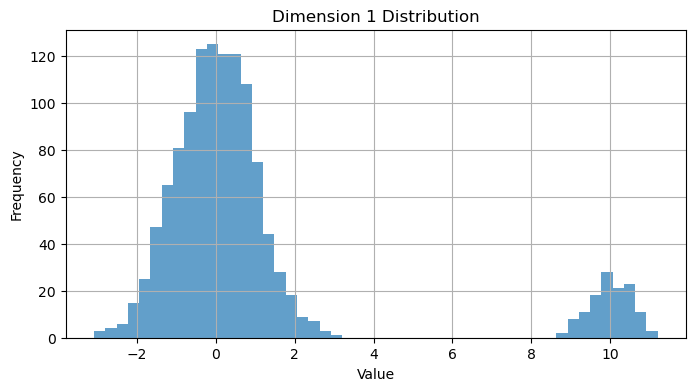

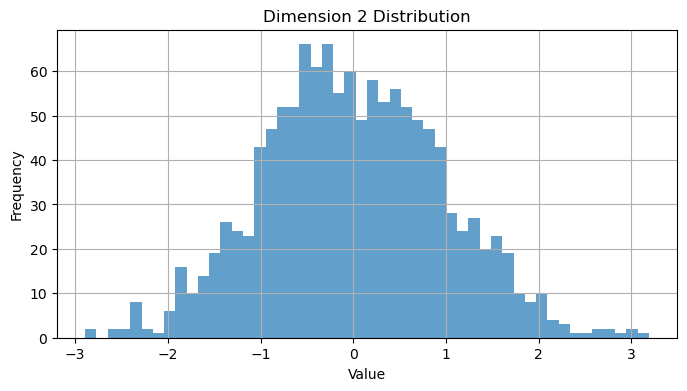

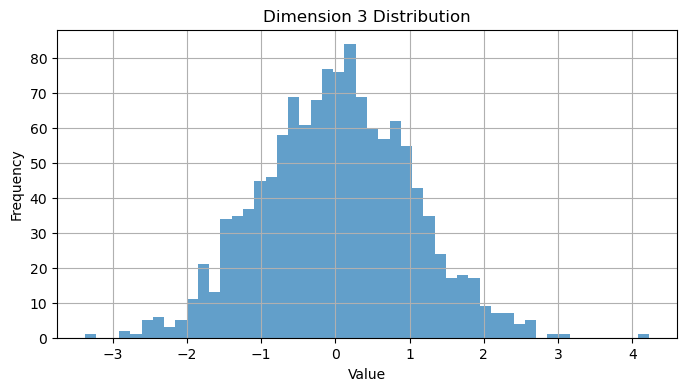

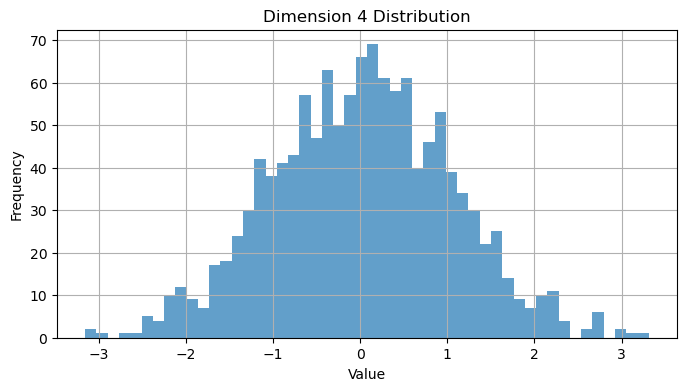

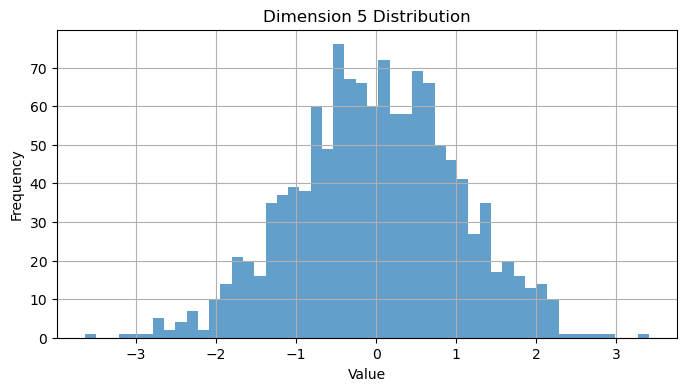

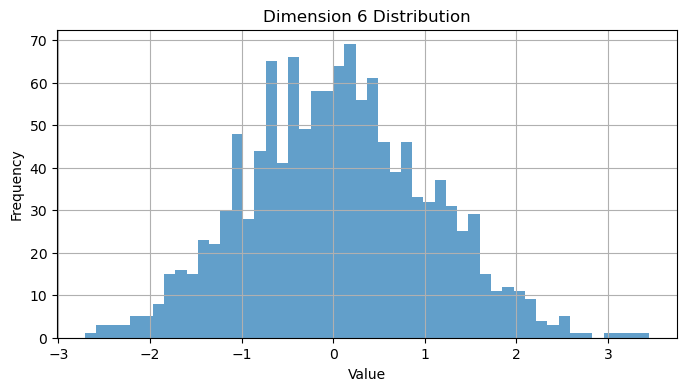

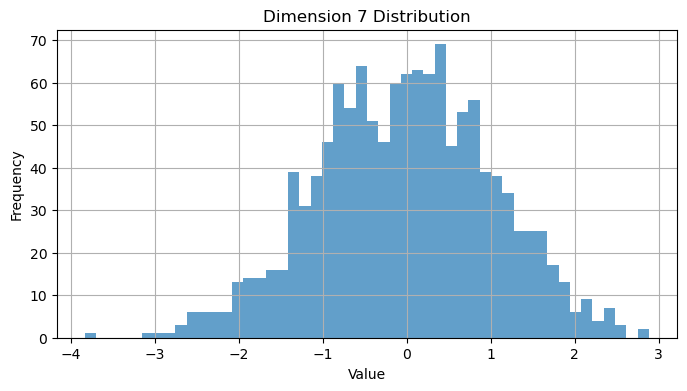

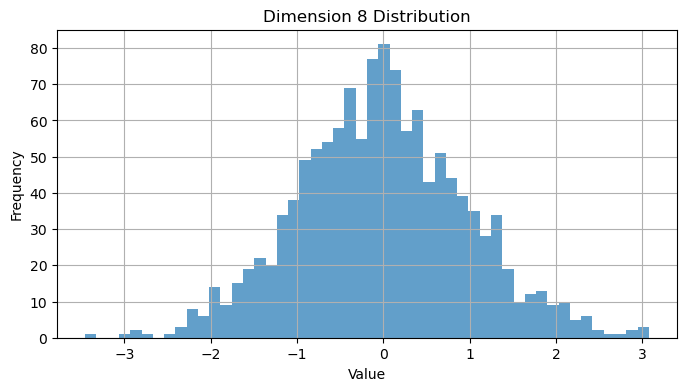

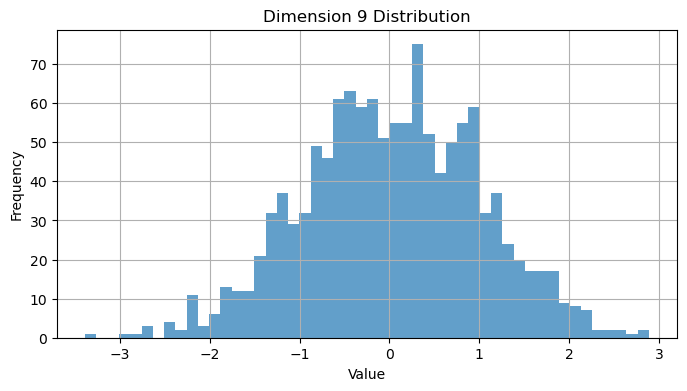

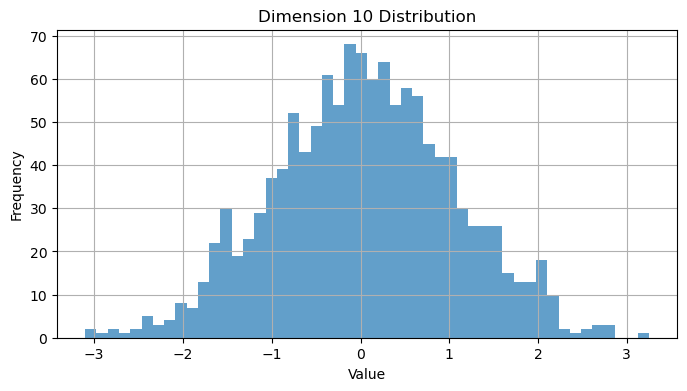

In [7]:
# Plot histograms for each dimension
for i in range(D):
    plt.figure(figsize=(8, 4))
    plt.hist(data[:, i].numpy(), bins=50, alpha=0.7)
    plt.title(f'Dimension {i+1} Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# Model

In [8]:
class MeanEstimator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.mean = nn.Parameter(torch.ones(input_dim))

    def forward(self, x):
        return self.mean.expand_as(x)  # Predict the same mean for all data points

In [9]:
def train_dp_model(train_loader, val_loader, epochs, learning_rate, max_grad_norm, epsilon, mixture_dim=0):
    # Initialize model and optimizer
    model = MeanEstimator(D)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Wrap model and optimizer with Opacus for DP
    privacy_engine = PrivacyEngine()
    model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        target_epsilon=epsilon,
        target_delta=1e-5,
        max_grad_norm=max_grad_norm,
        epochs=epochs,
        normalize_clipping=True,
    )

    criterion = nn.MSELoss()
    train_losses = []
    val_losses = []
    clipped_proportions = []

    # Training and validation loop
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0

        # Training phase
        for batch in train_loader:
            optimizer.zero_grad()

            # We have to extract the batch data this way,
            # because we don't have any targets
            batch_data = batch[0]

            # Output is the predicted mean
            output = model(batch_data)

            # Compute the loss as MSE between predicted mean and actual data
            loss = criterion(output, batch_data)
            loss.backward()

            # Calculate the proportion of clipped gradients
            total_gradients = 0
            clipped_gradients = 0
            for param in model.parameters():
                if param.grad_sample is not None:
                    total_gradients += param.grad_sample.numel()
                    clipped_gradients += (param.grad_sample.abs() > max_grad_norm).sum().item()

            clipped_proportion = clipped_gradients / total_gradients if total_gradients > 0 else 0
            clipped_proportions.append(clipped_proportion)

            optimizer.step()
            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                val_data = batch[0]
                val_output = model(val_data)  # Output is the predicted mean
                val_loss = criterion(val_output, val_data)  # Compare predicted mean with actual data
                epoch_val_loss += val_loss.item()

        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

    # Unwrap the vanilla model from Opacus
    vanilla_model = model.to_standard_module()

    # Record the norm of the predicted mean
    predicted_mean_norm_train = torch.norm(vanilla_model.mean).item()
    predicted_mean_norm_val = torch.norm(vanilla_model.mean).item()

    return (
        train_losses[-1],
        val_losses[-1],
        clipped_proportions,
        predicted_mean_norm_train,
        predicted_mean_norm_val
    )


# Experiment 1

In [10]:
def plot_results_combined(max_grad_norms, train_results_dict, val_results_dict):
    plt.figure(figsize=(12, 8))
    
    # Consistent colors for epsilons
    colors = plt.cm.viridis(np.linspace(0, 1, len(train_results_dict)))

    for i, (epsilon, train_losses) in enumerate(train_results_dict.items()):
        val_losses = val_results_dict[epsilon]

        # Plot training losses with dotted lines
        plt.plot(max_grad_norms, train_losses, linestyle='--', color=colors[i], marker='o', label=f"Training Loss (ε = {epsilon})")
        
        # Plot validation losses with solid lines
        plt.plot(max_grad_norms, val_losses, linestyle='-', color=colors[i], marker='x', label=f"Validation Loss (ε = {epsilon})")

    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('MSE Loss')
    plt.title('Effect of Maximum Gradient Norm on Toy Model')
    plt.legend()
    plt.grid(True)
    #plt.ylim([0,5])
    plt.savefig(f'temp/toy-model-all-epsilons.png')
    plt.show()


In [11]:
def plot_clipped_proportions_per_iteration_old_cmap(max_grad_norms, clipped_proportions_dict):
    colors = plt.cm.viridis(np.linspace(0, 1, len(max_grad_norms)))

    for i, epsilon in enumerate(clipped_proportions_dict.keys()):
        plt.figure(figsize=(10, 6))
        
        for idx, mgn in enumerate(max_grad_norms):
            # Get the clipped proportions for the current epsilon and max_grad_norm
            clipped_proportions = clipped_proportions_dict[epsilon][idx]

            # Plot them
            plt.plot(clipped_proportions, color=colors[idx], label=f'MGN = {mgn:.4f}')

        plt.xlabel('Iteration')
        plt.ylabel('Proportion of Clipped Gradients')
        plt.title(f'Proportion of clipped gradients vs. Iteration (Epsilon = {epsilon})')
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1,1))
        plt.tight_layout()
        plt.savefig(f'temp/proportion-of-clipped-gradients-epsilon{epsilon}.png')
        plt.show()

In [12]:
def plot_clipped_proportions_per_iteration(max_grad_norms, clipped_proportions_dict):
    cmap = plt.colormaps['tab20']

    for i, epsilon in enumerate(clipped_proportions_dict.keys()):
        plt.figure(figsize=(10, 6))
        
        for idx, mgn in enumerate(max_grad_norms):
            # Get the clipped proportions for the current epsilon and max_grad_norm
            clipped_proportions = clipped_proportions_dict[epsilon][idx]

            # Plot them with distinguishable colors
            plt.plot(clipped_proportions, color=cmap(idx % cmap.N), label=f'MGN = {mgn:.4f}')

        plt.xlabel('Iteration')
        plt.ylabel('Proportion of Clipped Gradients')
        plt.title(f'Proportion of clipped gradients vs. Iteration (Epsilon = {epsilon})')
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1,1))
        plt.tight_layout()
        plt.savefig(f'temp/proportion-of-clipped-gradients-epsilon{epsilon}.png')
        plt.show()


In [13]:
def plot_last_clipped_proportion_vs_mgn(max_grad_norms, clipped_proportions_dict):
    plt.figure(figsize=(10, 6))

    colors = plt.cm.viridis(np.linspace(0, 1, len(clipped_proportions.keys())))

    for i, (epsilon, proportions_list) in enumerate(clipped_proportions_dict.items()):
        # Extract the proportion of clipped gradients for the last iteration
        last_clipped_proportions = [proportions[-1] for proportions in proportions_list]

        # Plot the last clipped proportions as a function of max_grad_norm
        plt.plot(max_grad_norms, last_clipped_proportions, color=colors[i], marker='o', label=f'Epsilon = {epsilon}')

    plt.xscale('log')
    plt.xlabel('Max Gradient Norm (Log Scale)')
    plt.ylabel('Proportion of clipped gradients (Last Iteration)')
    plt.title('Proportion of clipped Gradients vs. Max Gradient Norm')
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.savefig('temp/proportion-of-clipped-gradients-vs-mgn-last-iteration.png')
    plt.show()

In [14]:
def plot_predicted_means(max_grad_norms, predicted_means_train_dict, predicted_means_val_dict):
    epsilons = predicted_means_train_dict.keys()

    for epsilon in epsilons:
        plt.figure(figsize=(10, 6))

        # Plot the final predicted means for training data
        final_train_means = [predicted_means_train_dict[epsilon][i] for i in range(len(max_grad_norms))]
        plt.plot(max_grad_norms, final_train_means, label='Training', marker='o', linestyle='--')

        # Plot the final predicted means for validation data
        final_val_means = [predicted_means_val_dict[epsilon][i] for i in range(len(max_grad_norms))]
        plt.plot(max_grad_norms, final_val_means, label='Validation', marker='x', linestyle='-')

        # Set plot details
        plt.xscale('log')  # Log scale for max_grad_norm if appropriate
        plt.xlabel('Max Gradient Norm')
        plt.ylabel('Final Predicted Mean Norm')
        plt.title(f'Final Predicted Mean Norms for Epsilon = {epsilon}') 
        plt.legend()
        plt.savefig(f'temp/predicted-mean-norms-epsilon{epsilon}.png')
        plt.grid(True)
        plt.show()


In [15]:
def plot_predicted_means_all_epsilons(max_grad_norms, predicted_means_train_dict, predicted_means_val_dict):
    epsilons = list(predicted_means_train_dict.keys())

    palette = sns.color_palette('tab10', len(epsilons))

    plt.figure(figsize=(10, 6))

    for idx, epsilon in enumerate(epsilons):
        color = palette[idx]

        # Plot the last iteration predicted means
        final_train_means = [predicted_means_train_dict[epsilon][i] for i in range(len(max_grad_norms))]
        plt.plot(max_grad_norms, final_train_means, label=f'Training, Epsilon={epsilon}', marker='o', linestyle='--', color=color)

        final_val_means = [predicted_means_val_dict[epsilon][i] for i in range(len(max_grad_norms))]
        plt.plot(max_grad_norms, final_val_means, label=f'Validation, Epsilon={epsilon}', marker='x', linestyle='-', color=color)

    plt.xscale('log')
    plt.xlabel('Max Gradient Norm')
    plt.ylabel('Last Iteration Predicted Mean Norm')
    plt.title(f'Last Iteration Predicted Mean Norms Across All Epsilons') 
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'temp/predicted-mean-norms-all-epsilons.png')
    plt.show()


In [16]:
def experiment1():
    epsilon_values = [0.125, 0.25, 1]
    
    # Store results for all epsilon values
    train_results_dict = {}
    val_results_dict = {}
    clipped_proportions_dict = {}
    predicted_means_train_dict = {}
    predicted_means_val_dict = {}

    for epsilon in epsilon_values:
        print(f'Running for epsilon: {epsilon}')

        seed_everything(seed)
        
        # Compute results for all max_grad_norms
        results = [
            train_dp_model(TRAIN_LOADER, VAL_LOADER, epochs=EPOCHS, learning_rate=LEARNING_RATE, max_grad_norm=mgn, epsilon=epsilon)
            for mgn in MAX_GRAD_NORMS
        ]
        
        # Unpack results into separate lists for train losses, val losses, clipped proportions, and predicted means
        train_losses, val_losses, clipped_proportions, predicted_means_train, predicted_means_val = zip(*results)
        
        # Store the results in the dictionaries
        train_results_dict[epsilon] = train_losses
        val_results_dict[epsilon] = val_losses
        clipped_proportions_dict[epsilon] = clipped_proportions
        predicted_means_train_dict[epsilon] = predicted_means_train
        predicted_means_val_dict[epsilon] = predicted_means_val
    
    return train_results_dict, val_results_dict, clipped_proportions_dict, predicted_means_train_dict, predicted_means_val_dict


In [17]:
train_losses, val_losses, clipped_proportions, train_means, val_means = experiment1()

Running for epsilon: 0.125


/home/arehn/git/opacus-decouple/opacus/privacy_engine.py:95: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/home/arehn/git/opacus-decouple/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/torch/nn/modules/module.py:1344: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


Running for epsilon: 0.25
Running for epsilon: 1


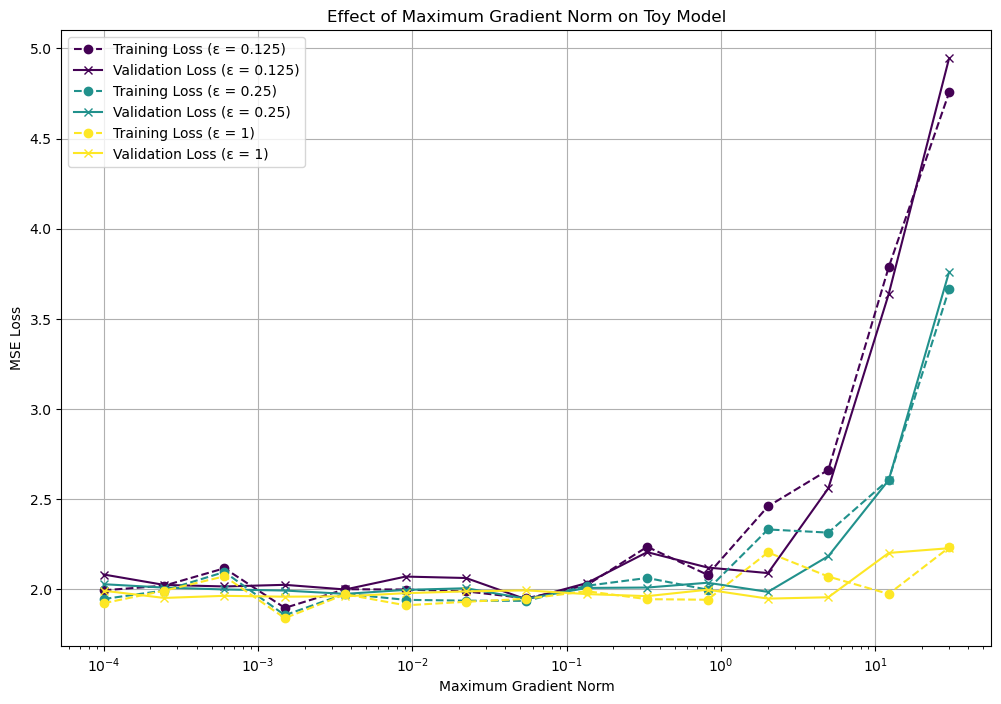

In [18]:
plot_results_combined(MAX_GRAD_NORMS, train_losses, val_losses)

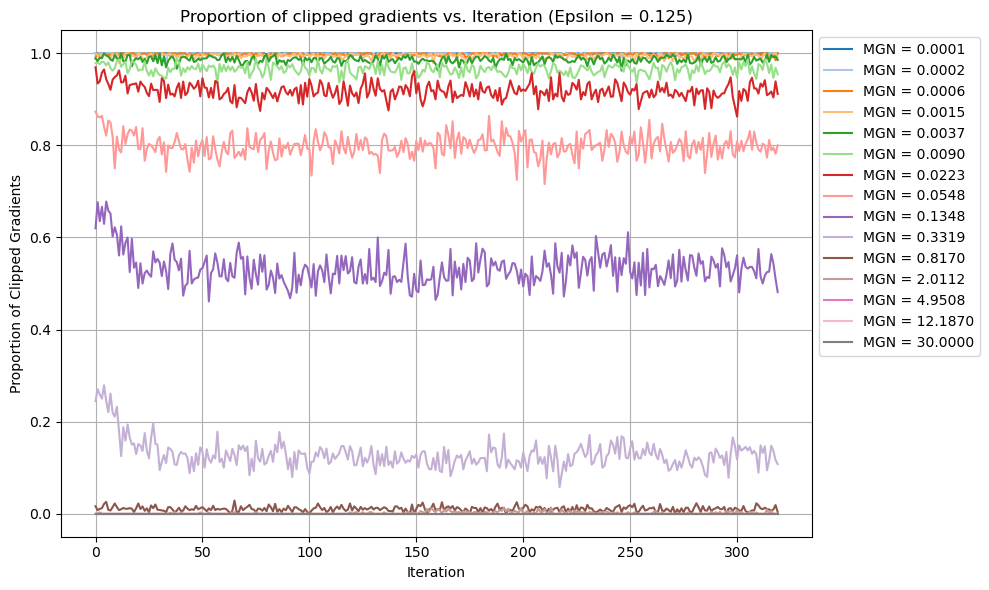

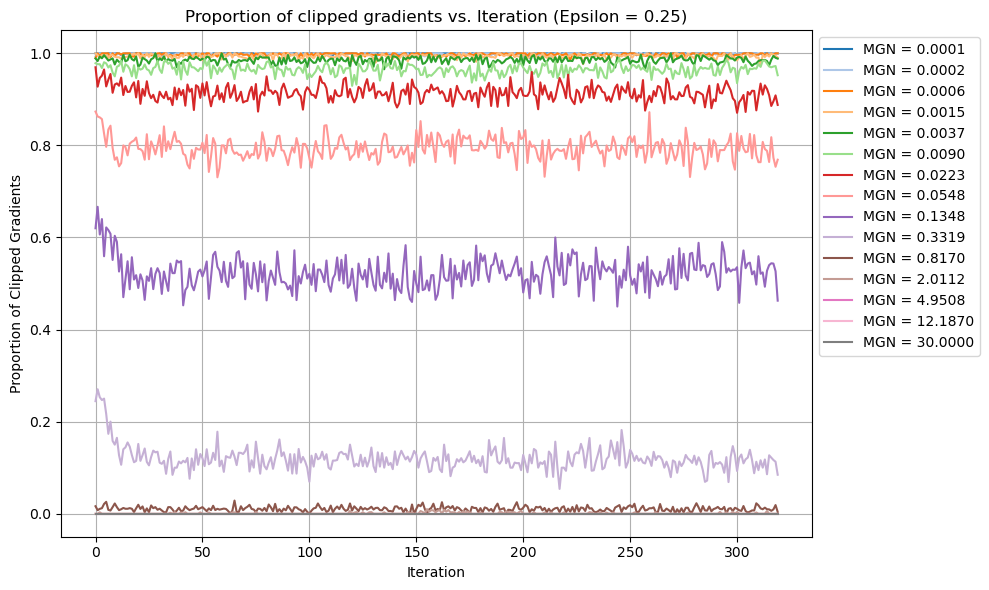

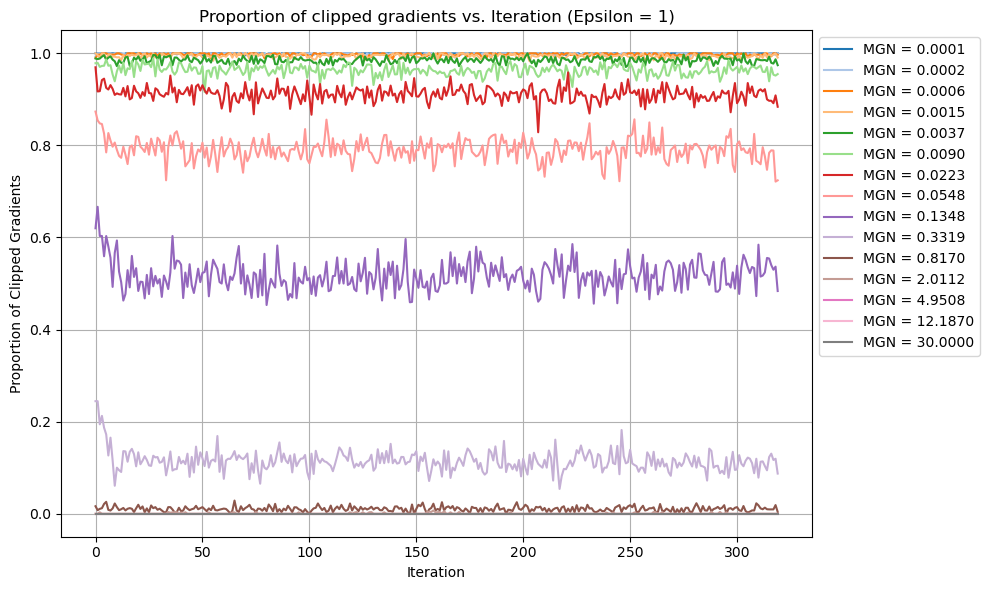

In [19]:
plot_clipped_proportions_per_iteration(MAX_GRAD_NORMS, clipped_proportions)

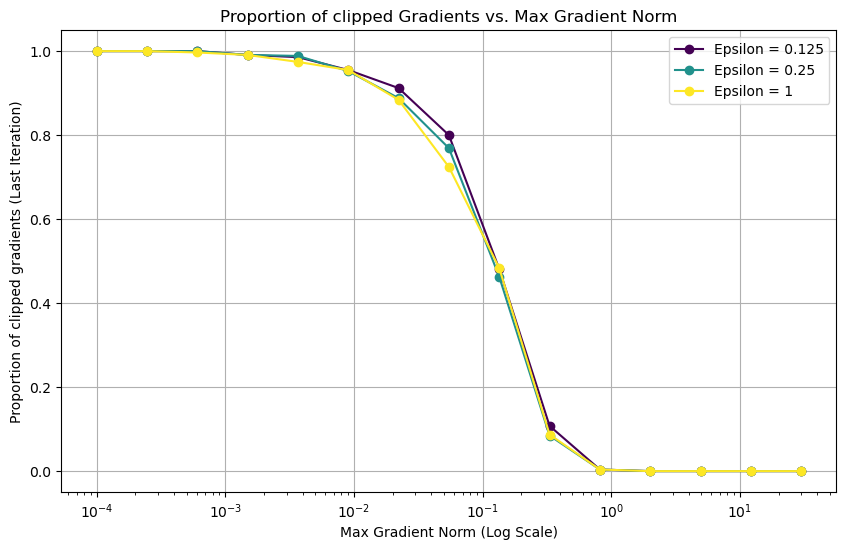

In [20]:
plot_last_clipped_proportion_vs_mgn(MAX_GRAD_NORMS, clipped_proportions)

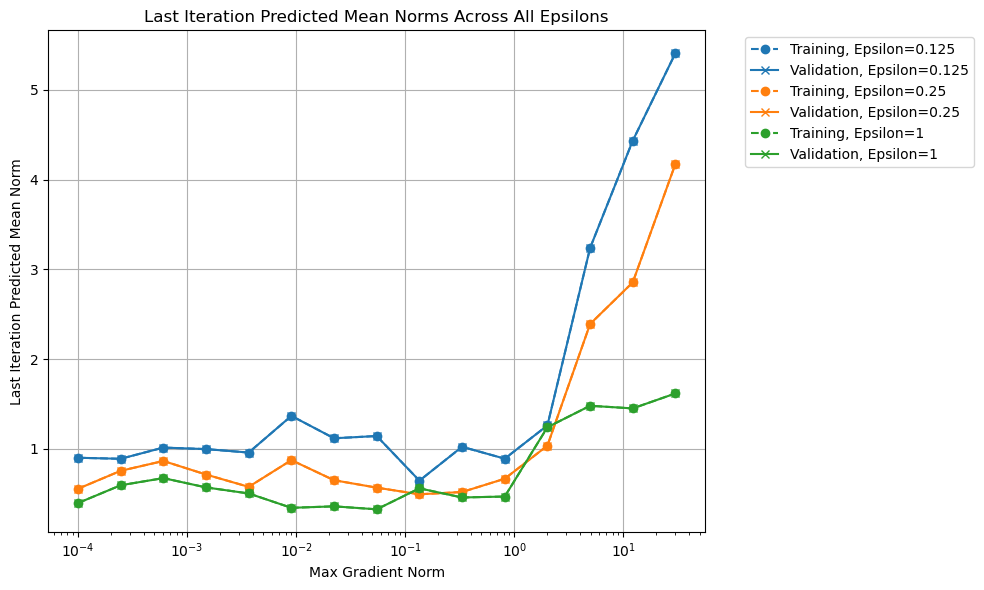

In [21]:
plot_predicted_means_all_epsilons(MAX_GRAD_NORMS, train_means, val_means)

# Experiment 2

In [45]:
def plot_mean_with_confidence_intervals(max_grad_norms, all_results_dict, n_repeats, epsilon, save_fname=None):
    means = []
    conf_intervals = []

    # Calculate mean and confidence intervals for each max_grad_norm
    for mgn in max_grad_norms:
        losses = all_results_dict[mgn]
        mean_loss = np.mean(losses)
        std_dev = np.std(losses)
        conf_interval = 1.96 * (std_dev / np.sqrt(len(losses)))

        means.append(mean_loss)
        conf_intervals.append(conf_interval)

    # Plot mean line with confidence intervals
    plt.figure(figsize=(12, 8))
    plt.plot(max_grad_norms, means, color='b', marker='o', label='Mean MSE Loss')
    plt.fill_between(max_grad_norms, np.array(means) - np.array(conf_intervals), np.array(means) + np.array(conf_intervals), color='b', alpha=0.2, label='95% CI')
    
    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('Mean MSE Loss')
    plt.title(f'Mean MSE Loss with 95% Confidence Intervals ({n_repeats} repeats) (ε = {epsilon})')
    plt.legend()
    plt.ylim([0,5])
    plt.grid(True)
    
    if save_fname:
        plt.savefig(save_fname)

    plt.show()


In [46]:
def plot_all_repeats(max_grad_norms, all_results, n_repeats, epsilon, save_fname=None):
    plt.figure(figsize=(12, 8))

    # Iterate over each repeat
    for i, repeat_losses in enumerate(all_results):
        # Plot each repeat's results as a separate line
        plt.plot(max_grad_norms, repeat_losses, alpha=0.5, color='blue', linewidth=0.5)

    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('MSE Loss')
    plt.title(f'All {n_repeats} Repeats for MSE Losses (ε = {epsilon})')
    plt.grid(True)
    plt.ylim([0,5])
    
    if save_fname:
        plt.savefig(save_fname)

    plt.show()

In [24]:
def experiment2():
    n_repeats = 100
    epsilon = 0.25
    all_results_dict = {mgn: [] for mgn in MAX_GRAD_NORMS}  # For confidence intervals
    all_results_list = []  # For plotting all the repeats separately
    
    for i in range(n_repeats):
        print(f'* Running repeat {i+1}..')
        repeat_losses = []
        seed_everything(seed+i)
        
        # Compute results for all max_grad_norms
        for mgn in MAX_GRAD_NORMS:
            train_loss, val_loss, _ = train_dp_model(
                TRAIN_LOADER,
                VAL_LOADER,
                epochs=EPOCHS,
                learning_rate=LEARNING_RATE,
                max_grad_norm=mgn,
                epsilon=epsilon,
            )
            all_results_dict[mgn].append(val_loss)
            repeat_losses.append(val_loss)
            
        all_results_list.append(repeat_losses)
    
    plot_all_repeats(
        MAX_GRAD_NORMS,
        all_results_list,
        n_repeats,
        epsilon,
        save_fname=f'temp/toy-model-epsilon-{epsilon}-{n_repeats}-repeats-raw-data.png',
    )

    plot_mean_with_confidence_intervals(
        MAX_GRAD_NORMS,
        all_results_dict,
        n_repeats,
        epsilon,
        save_fname=f'temp/toy-model-epsilon-{epsilon}-{n_repeats}-repeats-mean-with-confidence.png',
    )

    return all_results_dict, all_results_list

In [25]:
#losses_dict, losses_list = experiment2()

In [26]:
# n_repeats = 100
# epsilon = 0.25

# plot_mean_with_confidence_intervals(
#     MAX_GRAD_NORMS,
#     losses_dict,
#     n_repeats,
#     epsilon,
#     'temp/mixture-confidence-intervals.png',
# )

# Experiment 3

In [27]:
def experiment3():
    epsilon = 0.25
    initial_repeats = 100
    final_repeats = 800
    # Store results here
    all_results_dict = {mgn: [] for mgn in MAX_GRAD_NORMS}  # For confidence intervals
    all_results_list = []  # For plotting all the repeats separately
    
    def run_experiments(n_repeats):        
        for i in range(n_repeats):
            print(f'* Running repeat {i+1}..')
            seed_everything(seed+i)

            repeat_losses = []
            for mgn in MAX_GRAD_NORMS:
                train_loss, val_loss, _ = train_dp_model(
                    TRAIN_LOADER,
                    VAL_LOADER,
                    epochs=EPOCHS,
                    learning_rate=LEARNING_RATE,
                    max_grad_norm=mgn,
                    epsilon=epsilon,
                )
                
                all_results_dict[mgn].append(val_loss)  # Collect validation losses
                repeat_losses.append(val_loss)
                
            all_results_list.append(repeat_losses)
    
    current_repeats = initial_repeats
    while current_repeats <= final_repeats:
        print(f'Running with {current_repeats} repeats...')
        run_experiments(current_repeats)
                
        plot_all_repeats(
            MAX_GRAD_NORMS,
            all_results_list,
            current_repeats,
            epsilon,
            f'temp/toy-model-epsilon-{epsilon}-{current_repeats}-repeats-raw-data.png',
        )
        plot_mean_with_confidence_intervals(
            MAX_GRAD_NORMS,
            all_results_dict,
            current_repeats,
            epsilon,
            save_fname=f'temp/toy-model-epsilon-{epsilon}-{current_repeats}-repeats-mean-with-confidence.png',
        )
    
        current_repeats *= 2

    return all_results_dict, all_results_list

In [28]:
#losses_dict, losses_list = experiment3()

# Experiment 4

In [29]:
def objective(trial: optuna.trial.Trial, max_grad_norm: float):
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1.0)
    batch_size = trial.suggest_int('batch_size', 8, 1000)
    epochs = EPOCHS
    epsilon = 0.25

    print(f'*** Running with max_grad_norm: {max_grad_norm}, learning_rate: {learning_rate}, batch_size: {batch_size}')

    # Create data loaders
    train_loader = DataLoader(TRAIN_DATASET, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(VAL_DATASET, batch_size=len(VAL_DATASET), shuffle=False)

    train_loss, val_loss, _, _, _ = train_dp_model(train_loader, val_loader, epochs, learning_rate, max_grad_norm, epsilon)
    print(f'****** Training Loss: {train_loss}, Validation Loss: {val_loss}')

    return val_loss  # We want to minimize validation loss

In [30]:
def optimize(max_grad_norm, n_trials: int = 20, direction: str ='minimize', seed: int = 42):
    seed_everything(seed)

    sampler_cls = getattr(optuna.integration, 'BoTorchSampler')
    sampler = sampler_cls(seed=seed)

    study = optuna.create_study(
        storage='sqlite:///optuna-toy-model.db',
        study_name=f'dp_toy_model_optimization-mgn{max_grad_norm:.5f}',
        sampler=sampler,
        direction=direction,
    )

    objective_func = partial(objective, max_grad_norm=max_grad_norm)
    
    study.optimize(
        objective_func,
        n_trials=n_trials,
        gc_after_trial=True,  # garbage collect after each trial
    )

    trial = study.best_trial
    print(f'Best objective value: {trial.value}', file=sys.stderr)
    print('Best parameters:', file=sys.stderr)
    for key, value in trial.params.items():
        print(f' - {key}: {value}', file=sys.stderr)

    return trial.value, trial.params

In [31]:
def plot_losses_vs_max_grad_norms(max_grad_norms, optimized_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(max_grad_norms, optimized_losses, marker='o', linestyle='-', color='b')
    plt.xscale('log')
    plt.xlabel('Max Gradient Norm')
    plt.ylabel('Loss')
    plt.title('Loss after HPO as a Function of Max Gradient Norm')
    plt.grid(True)
    #plt.ylim([0, 5])
    plt.savefig('temp/toy-model-epsilon-0.25-HPO.png')
    plt.show()


In [32]:
def experiment4():
    optimized_losses = []
    optimized_params = []
    
    total_start_time = time.time()
    
    for max_grad_norm in MAX_GRAD_NORMS:
        print(f'Optimizing for max_grad_norm: {max_grad_norm}')
        
        study_start_time = time.time()
        best_loss, best_params = optimize(max_grad_norm, n_trials=50, seed=seed)
        study_duration = time.time() - study_start_time
        print(f'Study for max_grad_norm {max_grad_norm} took {study_duration:.2f} seconds')
        
        optimized_losses.append(best_loss)
        optimized_params.append(best_params)
    
    total_duration = time.time() - total_start_time
    print(f'Total runtime for all studies: {total_duration:.2f} seconds')

    with open('./toy-model-data/optimized_losses.pkl', 'wb') as f:
        pickle.dump(optimized_losses, f)
    
    # Save optimized_params
    with open('./toy-model-data/optimized_params.pkl', 'wb') as f:
        pickle.dump(optimized_params, f)
    
    plot_losses_vs_max_grad_norms(MAX_GRAD_NORMS, optimized_losses)

    return optimized_losses, optimized_params

Optimizing for max_grad_norm: 0.0001


/tmp/ipykernel_388454/173559930.py:5: ExperimentalWarning: BoTorchSampler is experimental (supported from v2.4.0). The interface can change in the future.
  sampler = sampler_cls(seed=seed)
[I 2024-08-21 16:53:16,758] A new study created in RDB with name: dp_toy_model_optimization-mgn0.00010


*** Running with max_grad_norm: 0.0001, learning_rate: 0.37454637344617403, batch_size: 952


[I 2024-08-21 16:53:23,190] Trial 0 finished with value: 2.073606491088867 and parameters: {'learning_rate': 0.37454637344617403, 'batch_size': 952}. Best is trial 0 with value: 2.073606491088867.


****** Training Loss: 1.9695533514022827, Validation Loss: 2.073606491088867
*** Running with max_grad_norm: 0.0001, learning_rate: 0.731996621871987, batch_size: 602


...

/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/optuna_integration/botorch.py:931: ExperimentalWarning: logei_candidates_func is experimental (supported from v3.3.0). The interface can change in the future.
  candidates = self._candidates_func(


*** Running with max_grad_norm: 30.0, learning_rate: 0.2796825517239539, batch_size: 620


/home/arehn/git/opacus-decouple/opacus/privacy_engine.py:95: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/home/arehn/git/opacus-decouple/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/torch/nn/modules/module.py:1344: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
[I 2024-08-21 17:4

****** Training Loss: 3.3811146020889282, Validation Loss: 3.44439959526062
Study for max_grad_norm 30.0 took 158.97 seconds
Total runtime for all studies: 2951.51 seconds


Best objective value: 2.41898775100708
Best parameters:
 - learning_rate: 0.09131755212109816
 - batch_size: 1000


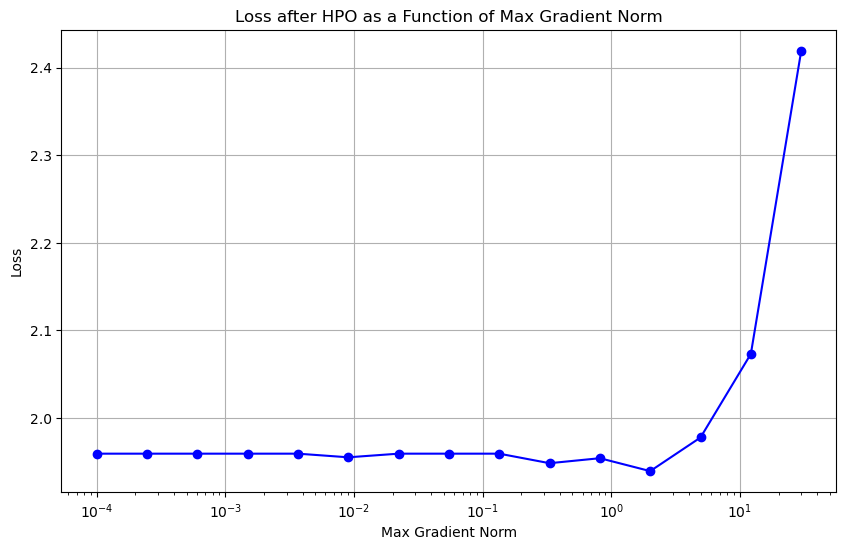

In [33]:
optimized_losses, optimized_params = experiment4()

# Experiment 5

In [34]:
def experiment_with_optimized_hypers(max_grad_norms, optimized_params, n, d, epochs, epsilon):
    initial_repeats = 200
    final_repeats = 200
        
    # Store results here
    all_results_dict = {mgn: [] for mgn in max_grad_norms}  # For confidence intervals
    all_results_list = []  # For plotting all the repeats separately
    
    # Function to incrementally run experiments
    def run_experiments(n_repeats):
        for i in range(n_repeats):
            print(f'* Running repeat {i+1}..')
            seed_everything(seed+i)

            repeat_losses = []
            for idx, mgn in enumerate(max_grad_norms):
                # Get optimized hyperparameters for this max_grad_norm
                params = optimized_params[idx]
                learning_rate = params['learning_rate']
                batch_size = params['batch_size']

                # Create data loaders
                train_loader = DataLoader(TRAIN_DATASET, batch_size=batch_size, shuffle=True)
                val_loader = DataLoader(VAL_DATASET, batch_size=len(VAL_DATASET), shuffle=False)

                # Train the model
                train_loss, val_loss, _, _, _ = train_dp_model(train_loader, val_loader, epochs, learning_rate, mgn, epsilon)
                
                all_results_dict[mgn].append(val_loss)  # Collect validation losses
                repeat_losses.append(val_loss)
                
            all_results_list.append(repeat_losses)
    
    # Main loop to double the repeats
    current_repeats = initial_repeats
    while current_repeats <= final_repeats:
        print(f'Running with {current_repeats} repeats...')
        run_experiments(current_repeats)
    
        # Plot the results after each iteration
        plot_all_repeats(
            max_grad_norms,
            all_results_list,
            current_repeats,
            epsilon,
            save_fname=f'temp/toy-model-HPO-epsilon-{epsilon}-{current_repeats}-repeats-raw-data.png',
        )
        plot_mean_with_confidence_intervals(
            max_grad_norms,
            all_results_dict,
            current_repeats,
            epsilon,
            save_fname=f'temp/toy-model-HPO-epsilon-{epsilon}-{current_repeats}-repeats-mean-with-confidence.png'
        )
    
        # Double the number of repeats for the next iteration
        current_repeats *= 2
    
    return all_results_list, all_results_dict

In [35]:
# with open('./toy-model-data/optimized_params-500trials.pkl', 'rb') as f:
#     optimized_params = pickle.load(f)

# with open('./toy-model-data/optimized_losses-500trials.pkl', 'rb') as f:
#     optimized_losses = pickle.load(f)

Running with 200 repeats...
* Running repeat 1..


/home/arehn/git/opacus-decouple/opacus/accountants/analysis/prv/prvs.py:52: RuntimeWarning: divide by zero encountered in log
  z = np.log(np.where(t > np.log(1 - q), (np.exp(t) + q - 1) / q, 1))
/home/arehn/git/opacus-decouple/opacus/accountants/analysis/prv/prvs.py:55: RuntimeWarning: divide by zero encountered in log
  t > np.log(1 - q),


* Running repeat 2..
* Running repeat 3..
* Running repeat 4..
* Running repeat 5..
* Running repeat 6..
* Running repeat 7..
* Running repeat 8..
* Running repeat 9..
* Running repeat 10..
* Running repeat 11..
* Running repeat 12..
* Running repeat 13..
* Running repeat 14..
* Running repeat 15..
* Running repeat 16..
* Running repeat 17..
* Running repeat 18..
* Running repeat 19..
* Running repeat 20..
* Running repeat 21..
* Running repeat 22..
* Running repeat 23..
* Running repeat 24..
* Running repeat 25..
* Running repeat 26..
* Running repeat 27..
* Running repeat 28..
* Running repeat 29..
* Running repeat 30..
* Running repeat 31..
* Running repeat 32..
* Running repeat 33..
* Running repeat 34..
* Running repeat 35..
* Running repeat 36..
* Running repeat 37..
* Running repeat 38..
* Running repeat 39..
* Running repeat 40..
* Running repeat 41..
* Running repeat 42..
* Running repeat 43..
* Running repeat 44..
* Running repeat 45..
* Running repeat 46..
* Running repeat 4

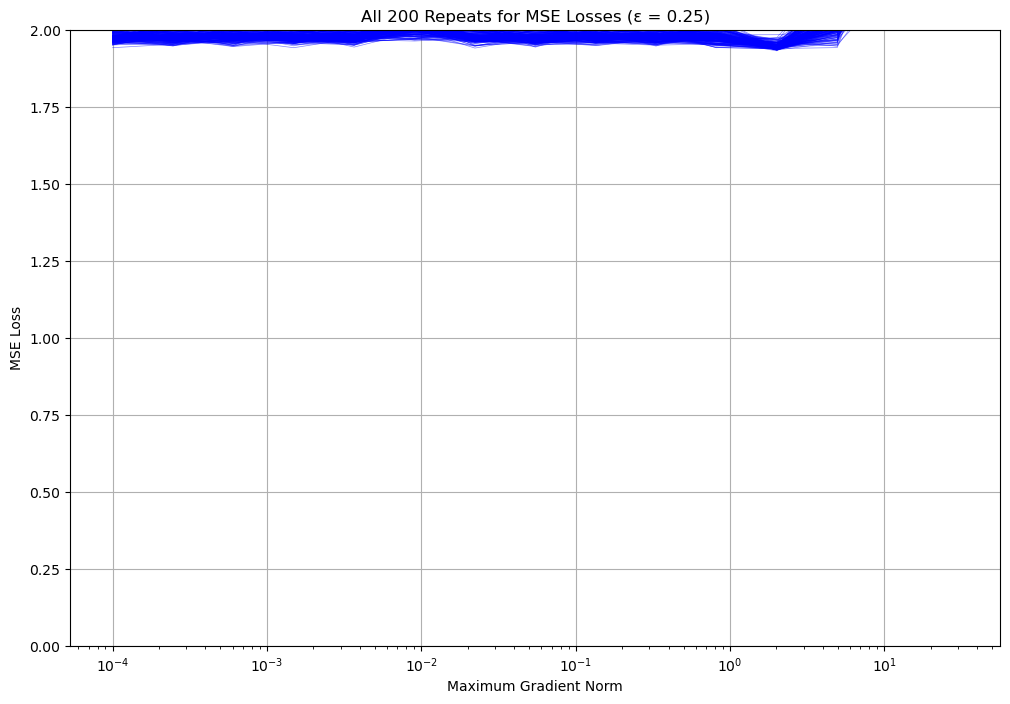

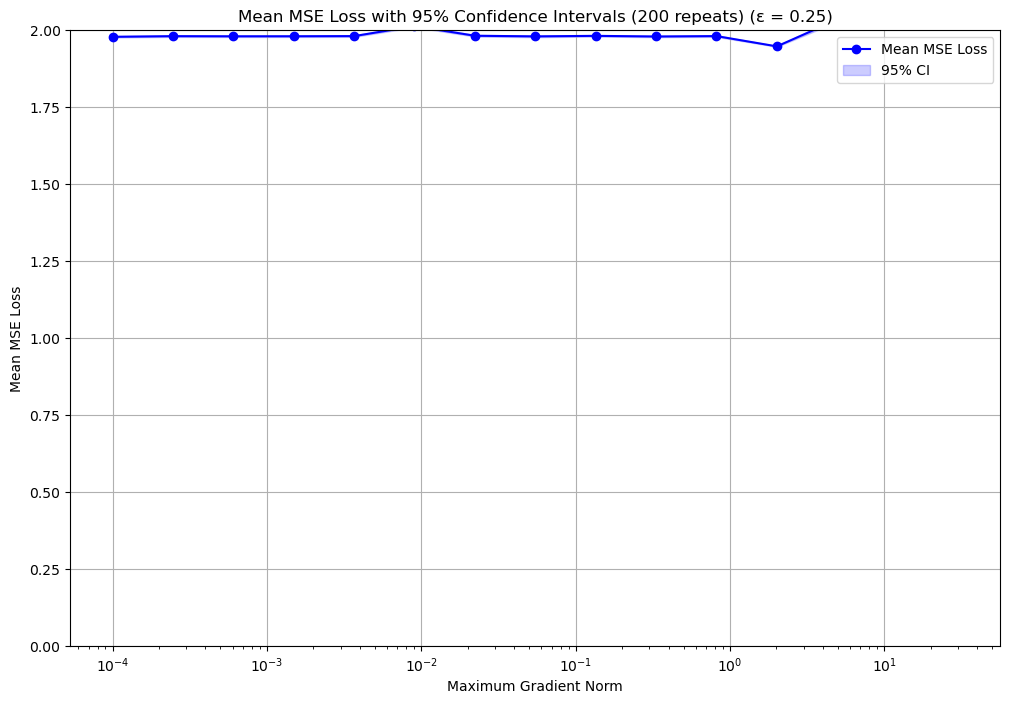

In [36]:
epsilon = 0.25

all_results_list, all_results_dict = experiment_with_optimized_hypers(
    MAX_GRAD_NORMS,
    optimized_params,
    N,
    D,
    EPOCHS,
    epsilon,
)

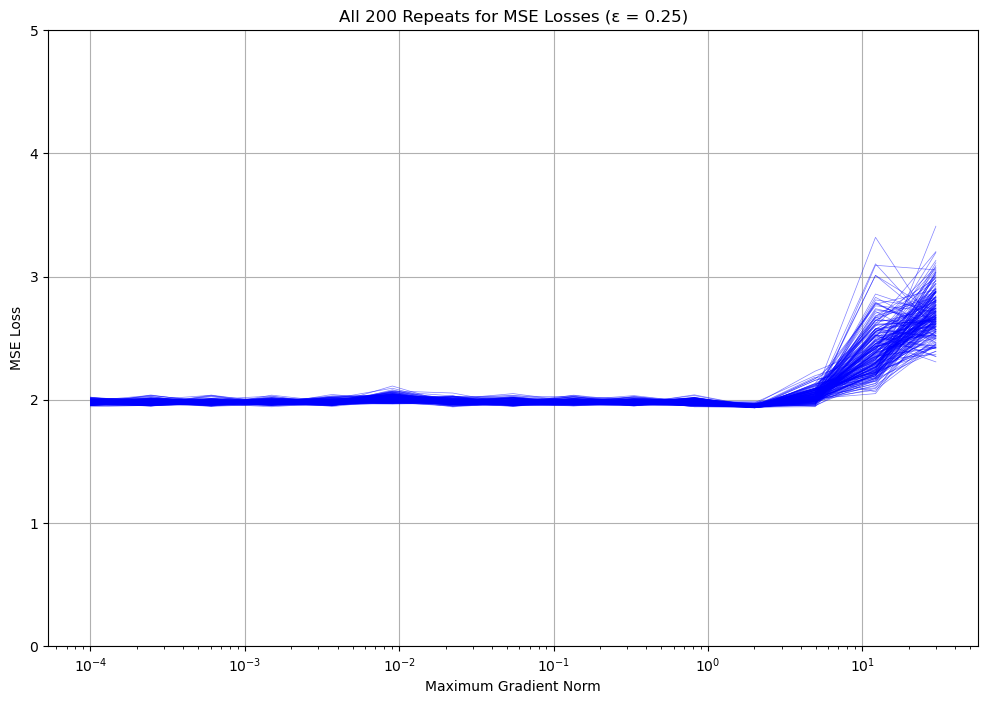

In [47]:
plot_all_repeats(
    MAX_GRAD_NORMS,
    all_results_list,
    200,
    0.25,
    save_fname=f'temp/toy-model-HPO-epsilon-0.25-200-repeats-raw-data-NEW.png',
)

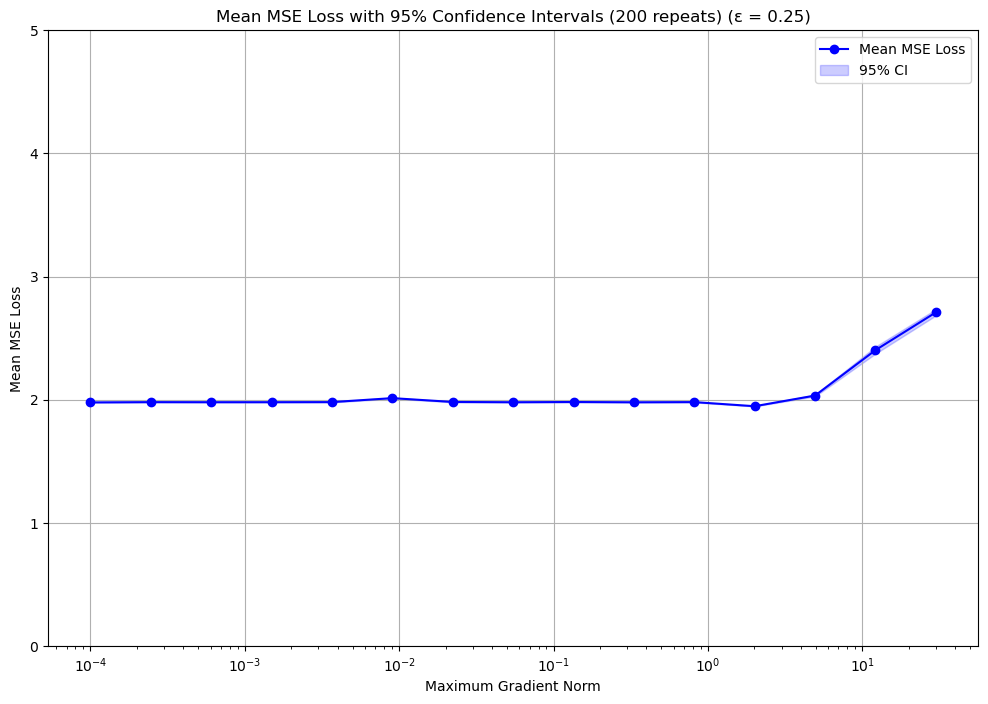

In [48]:
plot_mean_with_confidence_intervals(
    MAX_GRAD_NORMS,
    all_results_dict,
    200,
    0.25,
    save_fname=f'temp/toy-model-HPO-epsilon-0.25-200-repeats-mean-with-confidence-NEW.png'
)

# Experiment 6

In [39]:
def experiment6(optimized_params, epsilon=0.25):
    # Store results for all epsilon values
    train_results_dict = {}
    val_results_dict = {}
    clipped_proportions_dict = {}
    train_means_dict = {}
    val_means_dict = {}

    seed_everything(seed)

    results = []
    # Compute results for all max_grad_norms
    for i, mgn in enumerate(MAX_GRAD_NORMS):
        hypers = optimized_params[i]
        learning_rate = hypers['learning_rate']
        batch_size = hypers['batch_size']

        # Create data loaders
        train_loader = DataLoader(TRAIN_DATASET, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(VAL_DATASET, batch_size=len(VAL_DATASET), shuffle=False)

        result = train_dp_model(train_loader, val_loader, epochs=EPOCHS, learning_rate=learning_rate, max_grad_norm=mgn, epsilon=epsilon)
        results.append(result)
    
    # Unpack results into separate lists for train losses, val losses, and clipped proportions
    train_losses, val_losses, clipped_proportions, train_means, val_means = zip(*results)
    #print(f'TRAIN_LOSSES: {train_losses}')
    #print(f'TRAIN_MEANS: {train_means}')

    # Store the results in the dictionaries
    train_results_dict[epsilon] = train_losses
    val_results_dict[epsilon] = val_losses
    clipped_proportions_dict[epsilon] = clipped_proportions
    train_means_dict[epsilon] = train_means
    val_means_dict[epsilon] = val_means

    return train_results_dict, val_results_dict, clipped_proportions_dict, train_means_dict, val_means_dict

In [40]:
train_losses, val_losses, clipped_proportions, train_means, val_means = experiment6(optimized_params)

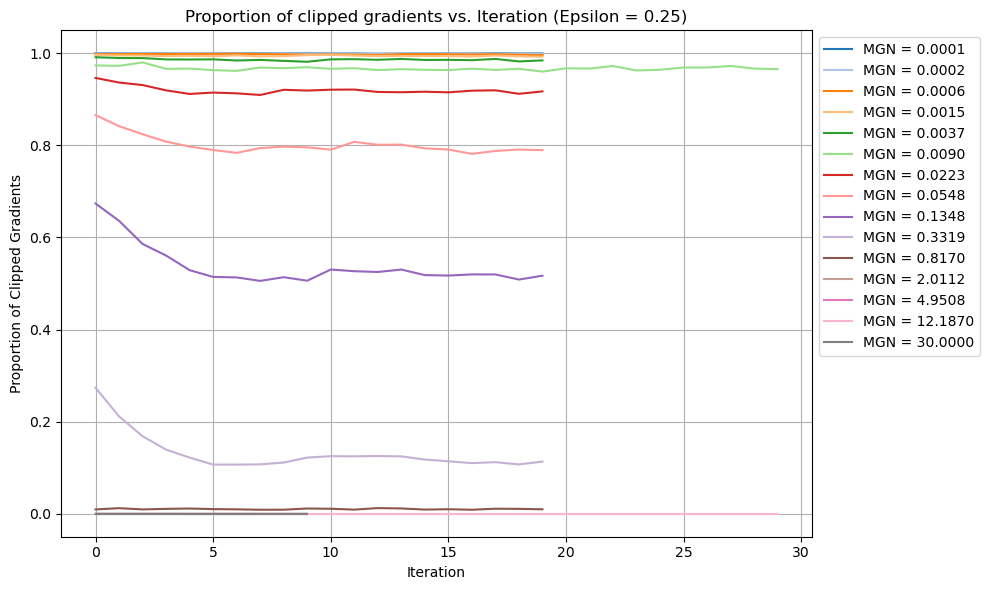

In [41]:
plot_clipped_proportions_per_iteration(MAX_GRAD_NORMS, clipped_proportions)

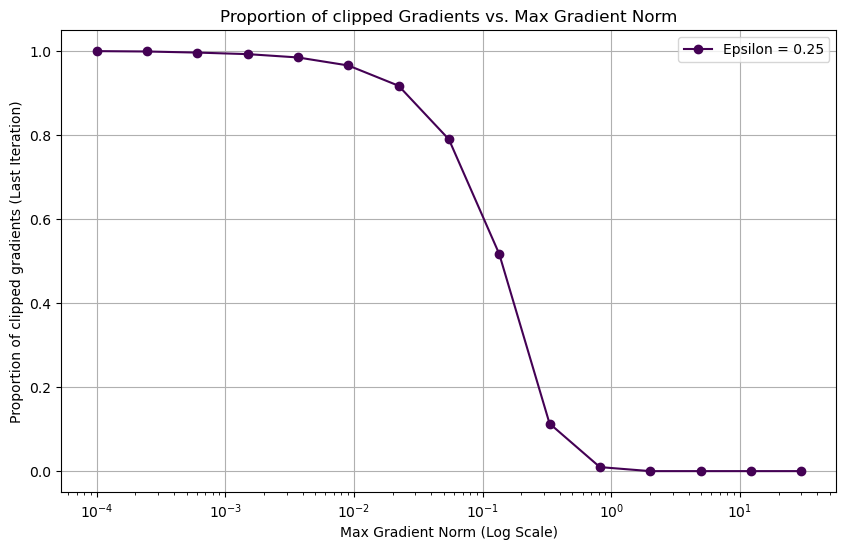

In [42]:
plot_last_clipped_proportion_vs_mgn(MAX_GRAD_NORMS, clipped_proportions)

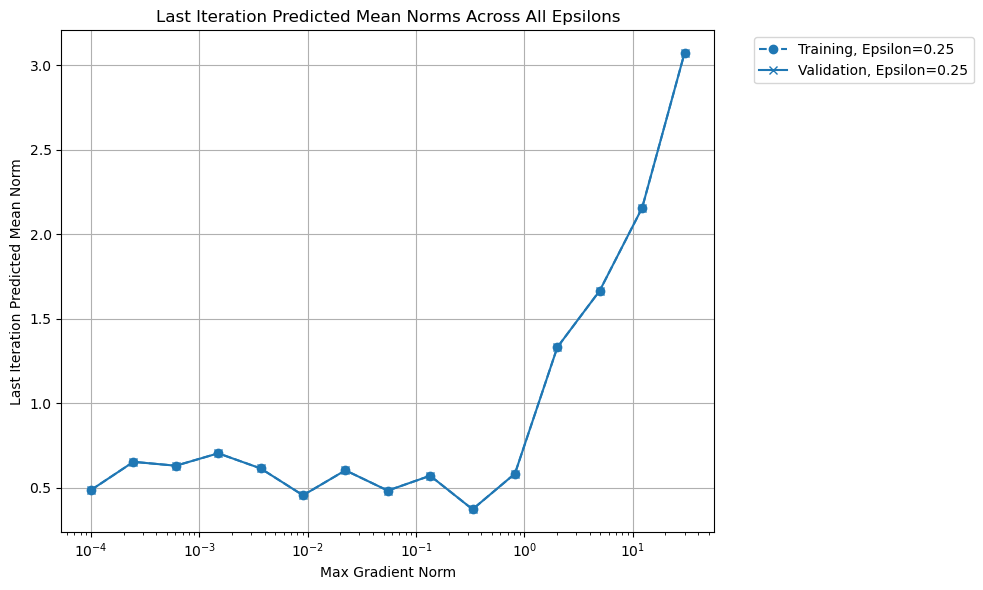

In [43]:
plot_predicted_means_all_epsilons(MAX_GRAD_NORMS, train_means, val_means)

In [44]:
clipped_proportions

{0.25: ([1.0,
   0.9997938144329896,
   0.9995951417004049,
   0.9996,
   0.9992248062015504,
   0.9995983935742971,
   0.9995959595959596,
   0.9998050682261208,
   0.9995867768595041,
   1.0,
   0.9996055226824457,
   0.9998039215686274,
   0.9991869918699187,
   0.999390243902439,
   0.9996108949416342,
   0.9995910020449897,
   0.999803536345776,
   1.0,
   0.999812382739212,
   0.9998019801980198],
  [0.9991967871485944,
   0.9991507430997877,
   0.9994094488188976,
   0.9985971943887776,
   0.9989837398373984,
   0.998995983935743,
   0.9985477178423237,
   0.9986407766990292,
   0.9986666666666667,
   0.9991935483870967,
   0.9994140625,
   0.9991853360488798,
   0.9995901639344262,
   0.9977955911823647,
   0.9989858012170385,
   0.9989837398373984,
   0.999792531120332,
   0.9987577639751553,
   0.9996,
   0.9989224137931034],
  [0.9981670061099797,
   0.9984126984126984,
   0.9986301369863013,
   0.9984031936127744,
   0.9988142292490119,
   0.9987854251012146,
   0.999074074